# Hands-On Workshop: AI Model Development using Python
### Satellite Land Cover Classification — CNN vs. Vision Transformer

**Faculty Development Programme**
**Date:** 30 July 2026 · **Time:** 9:30 – 11:15 AM

**Presented by:** Abhishek Kumar Shukla
**Senior AI Developer, UniConverge Technologies Pvt. Ltd.**

---

### What we will build today

By the end of this session, you will have trained **two different deep learning architectures** —
a convolutional neural network (CNN) and a Vision Transformer (ViT) — on the same land-cover
classification task, and directly compared them: accuracy, training time, parameter count, and where
each one gets confused. This mirrors a core theme from the "ML for Environmental & Resource Monitoring"
lecture: **architecture choice should follow your data and task constraints, not what's currently
trendy.**

We will use the **EuroSAT** dataset: 27,000 labeled Sentinel-2 image patches across 10 land-cover
classes, a standard benchmark in this field.

### Session flow (~105 minutes)

| Time | Section |
|---|---|
| 9:30 – 9:38 | 1. Setup & GPU check |
| 9:38 – 9:50 | 2. Load and explore the dataset |
| 9:50 – 10:02 | 3. Preprocess and build data pipelines |
| 10:02 – 10:15 | 4. Build & train the CNN |
| 10:15 – 10:22 | 5. Evaluate the CNN |
| 10:22 – 10:40 | 6. Build & train a Vision Transformer (ViT) |
| 10:40 – 10:48 | 7. Evaluate the ViT |
| 10:48 – 11:00 | 8. Head-to-head comparison: CNN vs. ViT |
| 11:00 – 11:15 | 9. Inference on your own image + wrap-up |

> **Before we start:** Go to `Runtime` → `Change runtime type` → select **T4 GPU** → `Save`.
> This is the single most important setup step — training will be 10–20x slower on CPU, and the
> Transformer section in particular will not fit our time window without a GPU.

---

## 1. Setup & GPU Check

Let's confirm the GPU is active and install/import everything we need.

In [1]:
# Confirm GPU is available — this should print a GPU device name, not an empty list
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices found:", tf.config.list_physical_devices('GPU'))

if len(tf.config.list_physical_devices('GPU')) == 0:
    print("\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU, then Runtime → Restart session.")
else:
    print("\n✅ GPU is ready. Let's go.")

TensorFlow version: 2.20.0
GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU is ready. Let's go.


In [2]:
# Pin tensorflow-metadata and protobuf to versions known to work together, BEFORE importing
# TensorFlow. The error some of you saw ("Detected incompatible Protobuf Gencode/Runtime
# versions") comes from tensorflow-metadata shipping generated code newer than the protobuf
# runtime Colab has preinstalled — pinning tensorflow-metadata down (not just upgrading
# protobuf) is what actually fixes it.
!pip install -q "protobuf==5.29.6" "tensorflow-metadata==1.17.1" "tensorflow-datasets>=4.9.7"
!pip install -q -U datasets

print("Packages installed.")
print("If pip printed any 'RESTART RUNTIME' notice above, do that now:")
print("Runtime -> Restart session, then Runtime -> Run all (from the top).")
print("This is a one-time step for a fresh Colab runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.8 MB/s eta 0:00:00
Packages installed.
If pip printed any 'RESTART RUNTIME' notice above, do that now:
Runtime -> Restart session, then Runtime -> Run all (from the top).
This is a one-time step for a fresh Colab runtime.


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices found:", tf.config.list_physical_devices('GPU'))

if len(tf.config.list_physical_devices('GPU')) == 0:
    print("\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU, then Runtime → Restart session.")
else:
    print("\n✅ GPU is ready. Let's go.")

import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print("Imports complete.")

TensorFlow version: 2.20.0
GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU is ready. Let's go.
Imports complete.


## 2. Load and Explore the Dataset

We're using **EuroSAT** — Sentinel-2 satellite patches, 64×64 pixels, RGB, across 10 land-cover classes.
`tensorflow_datasets` downloads and caches it automatically (~90 MB for the RGB version — this should
take under a minute on Colab's connection).

In [2]:
# Load EuroSAT from Hugging Face (RGB version). Downloads ~99MB on first run, cached after that.
from datasets import load_dataset as hf_load_dataset

hf_ds = hf_load_dataset("tanganke/eurosat")

class_names = hf_ds['train'].features['label'].names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training examples:", len(hf_ds['train']))
print("Test examples:", len(hf_ds['test']))

# IMPORTANT: both the train and test splits on Hugging Face are stored grouped by class —
# all "annual crop land" examples first, then all "forest" examples, and so on. tf.data's
# .shuffle() later only keeps a small buffer in memory, so it can't mix classes that are
# thousands of rows apart — and an unshuffled, class-sorted test set makes per-batch
# validation accuracy during training meaningless (each batch is almost entirely one class).
# We shuffle both splits at the source (fixed seed, for reproducibility) before converting
# to tf.data, so classes are already interleaved everywhere downstream.
hf_train_shuffled = hf_ds['train'].shuffle(seed=42)
hf_test_shuffled = hf_ds['test'].shuffle(seed=42)


def hf_split_to_tf_dataset(hf_split):
    """Convert a Hugging Face dataset split into a tf.data.Dataset of (image, label) pairs,
    matching what the rest of this notebook expects."""
    def gen():
        for example in hf_split:
            image = np.array(example['image'].convert('RGB'), dtype=np.uint8)
            label = example['label']
            yield image, label

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(64, 64, 3), dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        ),
    )


ds_train = hf_split_to_tf_dataset(hf_train_shuffled)
ds_test = hf_split_to_tf_dataset(hf_test_shuffled)

print("\nDatasets ready as ds_train / ds_test (same interface as before).")

README.md:   0%|          | 0.00/5.01k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 73.5MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.13MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating jpeg_compression split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Classes: ['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']
Number of classes: 10
Training examples: 21600
Test examples: 2700

Datasets ready as ds_train / ds_test (same interface as before).


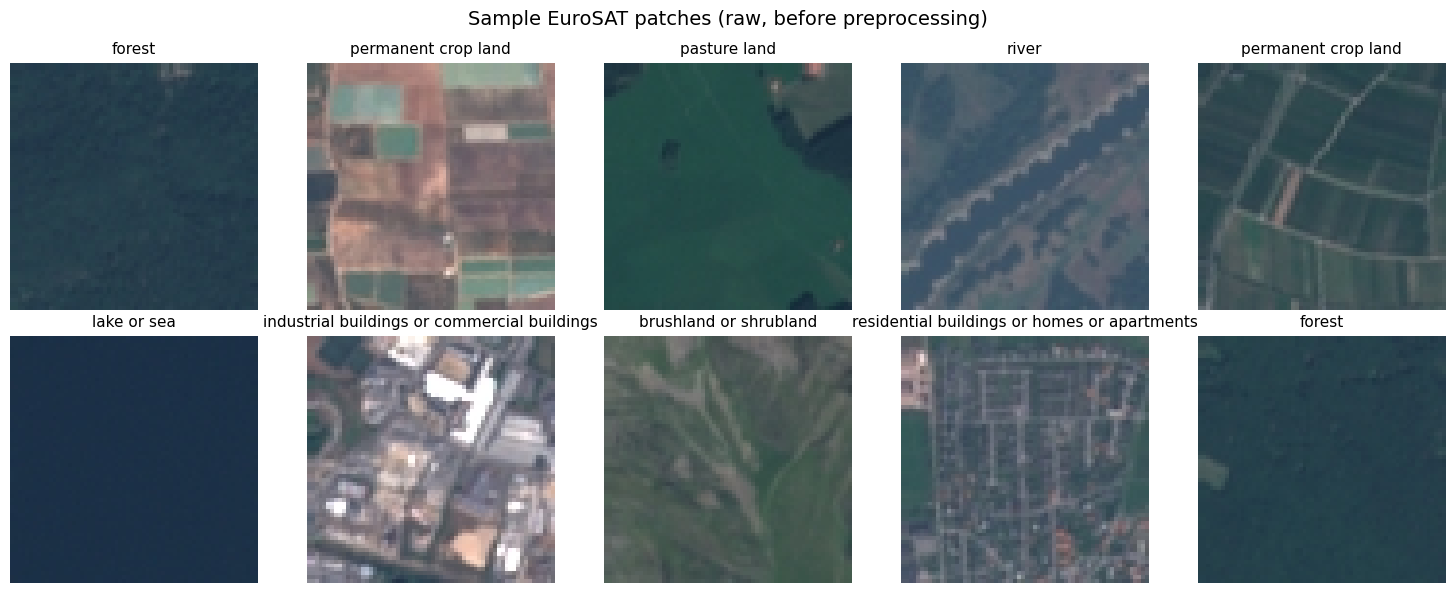

In [3]:
# Look at a few raw examples before we do anything to them
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, (image, label) in enumerate(ds_train.take(10)):
    ax = axes[i // 5, i % 5]
    ax.imshow(image.numpy())
    ax.set_title(class_names[label.numpy()], fontsize=11)
    ax.axis('off')
plt.suptitle("Sample EuroSAT patches (raw, before preprocessing)", fontsize=14)
plt.tight_layout()
plt.show()

### Quick discussion point

Notice these are only **64×64 pixel RGB patches** — EuroSAT ships a simplified RGB-only version for
teaching purposes. The full Sentinel-2 product has **13 spectral bands** including near-infrared, which
is what NDVI and real vegetation-health analysis actually use. We're deliberately using the RGB-only
version today to keep training fast within our time window — the same CNN architecture generalizes to
13-band input with a one-line change to the first layer, which we'll mention at the end.

In [4]:
# Check class balance — is every class equally represented?
import collections

label_counts = collections.Counter()
for _, label in ds_train:
    label_counts[class_names[label.numpy()]] += 1

for name, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"{name:25s} {count:5d}  {'█' * (count // 30)}")

residential buildings or homes or apartments  2431  █████████████████████████████████████████████████████████████████████████████████
lake or sea                2407  ████████████████████████████████████████████████████████████████████████████████
forest                     2390  ███████████████████████████████████████████████████████████████████████████████
brushland or shrubland     2381  ███████████████████████████████████████████████████████████████████████████████
annual crop land           2373  ███████████████████████████████████████████████████████████████████████████████
industrial buildings or commercial buildings  2012  ███████████████████████████████████████████████████████████████████
highway or road            2012  ███████████████████████████████████████████████████████████████████
permanent crop land        1995  ██████████████████████████████████████████████████████████████████
river                      1973  ███████████████████████████████████████████████████████████

## 3. Preprocess and Build Data Pipelines

Three things every image pipeline needs:
1. **Normalize** pixel values (0–255 → 0–1) so the network trains stably
2. **Batch** the data so the GPU processes many images at once, not one at a time
3. **Augment** the training set (random flips/rotations) so the model doesn't just memorize orientation

We will **not** augment the test set — we want to evaluate on realistic, unmodified images.

In [5]:
IMG_SIZE = 64
BATCH_SIZE = 32

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return image, label

# Training pipeline: normalize -> augment -> shuffle -> batch -> prefetch
train_pipeline = (
    ds_train
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test pipeline: normalize only -> batch -> prefetch (no augmentation, no shuffle)
test_pipeline = (
    ds_test
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines built.")
print("One training batch shape:", next(iter(train_pipeline))[0].shape)

Pipelines built.
One training batch shape: (32, 64, 64, 3)


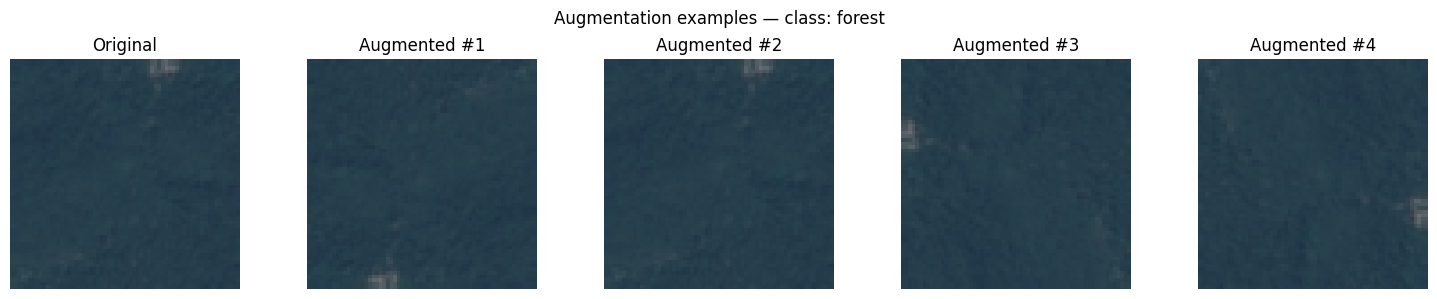

In [6]:
# Visualize what augmentation actually does to one image
sample_image, sample_label = next(iter(ds_train.map(normalize)))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(sample_image.numpy())
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 5):
    aug_image, _ = augment(sample_image, sample_label)
    axes[i].imshow(aug_image.numpy())
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis('off')

plt.suptitle(f"Augmentation examples — class: {class_names[sample_label.numpy()]}")
plt.tight_layout()
plt.show()

## 4a. Build the CNN Model

We'll build a compact convolutional neural network from scratch — small enough to train in minutes on a
Colab GPU, but structured the same way production land-cover classifiers are: stacked
**Conv → BatchNorm → ReLU → Pool** blocks that progressively extract more abstract features, followed
by a classification head.

This is the same conv-block pattern used inside the encoder half of a U-Net (the architecture used for
full pixel-wise segmentation, as opposed to today's per-image classification) — today's model
classifies what the whole patch is, while a U-Net would classify what every single pixel is.

In [7]:
from tensorflow.keras import layers, models

def build_cnn(input_shape=(64, 64, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # Classification head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

### What each piece is doing (for discussion)

- **Conv2D** — slides small filters across the image to detect local patterns (edges, textures); early
  layers learn simple patterns, deeper layers combine them into complex ones (e.g., "grid-like texture"
  → "urban area").
- **BatchNormalization** — keeps activations in a stable range during training, which speeds up
  convergence and lets us use a higher learning rate safely.
- **MaxPooling2D** — downsamples spatial resolution, which both reduces compute and forces the network
  to focus on *whether* a pattern is present rather than its *exact* pixel position.
- **GlobalAveragePooling2D** — collapses each feature map to a single number, dramatically fewer
  parameters than flattening, and less prone to overfitting on a dataset this size.
- **Dropout** — randomly zeroes 30% of connections during training only, a standard regularizer that
  prevents the model from over-relying on any single feature path.

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print("Model compiled and ready to train.")

Model compiled and ready to train.


## 4b. Train the CNN

We'll train for a small number of epochs to respect our time budget. On a Colab T4 GPU, each epoch over
~21,600 training images should take roughly 20–40 seconds.

In [9]:
EPOCHS = 8  # trimmed slightly to protect time budget for the ViT section later

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    ),
]

import time
cnn_train_start = time.time()

history = model.fit(
    train_pipeline,
    validation_data=test_pipeline,
    epochs=EPOCHS,
    callbacks=callbacks,
)

cnn_train_time = time.time() - cnn_train_start
cnn_param_count = model.count_params()
print(f"\nCNN training time: {cnn_train_time:.1f} seconds")
print(f"CNN parameter count: {cnn_param_count:,}")

Epoch 1/8
    671/Unknown 31s 32ms/step - accuracy: 0.5951 - loss: 1.1393

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


675/675 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.6818 - loss: 0.9022 - val_accuracy: 0.3722 - val_loss: 1.9896
Epoch 2/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7839 - loss: 0.6248 - val_accuracy: 0.2848 - val_loss: 3.9410
Epoch 3/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8311 - loss: 0.4981 - val_accuracy: 0.2511 - val_loss: 8.2240
Epoch 4/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8583 - loss: 0.4136 - val_accuracy: 0.7074 - val_loss: 0.9984
Epoch 5/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.8808 - loss: 0.3553 - val_accuracy: 0.4841 - val_loss: 2.4863
Epoch 6/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.8900 - loss: 0.3258 - val_accuracy: 0.4396 - val_loss: 3.5423
Epoch 7/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.9012 - loss: 0.2896 - val_accuracy: 0.5648 - val_loss: 2.2523

CNN training time: 181.0 seconds
CNN parameter count: 111,946


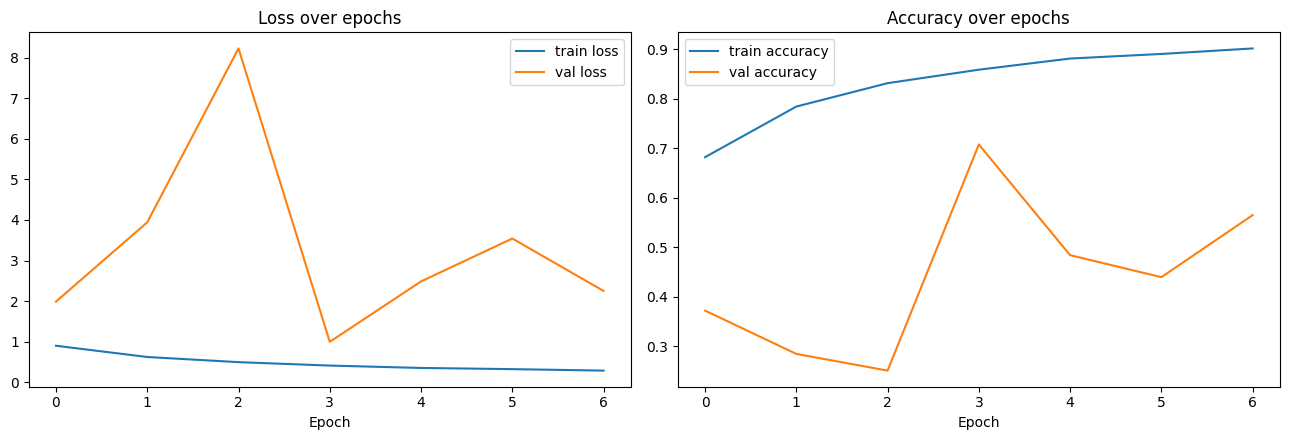

In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train accuracy')
axes[1].plot(history.history['val_accuracy'], label='val accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading these curves — what to look for

- **Train and validation curves close together, both improving** → healthy training.
- **Train accuracy much higher than validation accuracy** → overfitting; the model is memorizing rather
  than generalizing. Fixes: more augmentation, more dropout, or more training data.
- **Both curves flat and low from the start** → underfitting; the model may need more capacity, more
  epochs, or a higher learning rate.
- **Validation loss increasing while validation accuracy holds steady** → the model is becoming
  overconfident on wrong predictions; often addressed with stronger regularization.

## 5. Evaluate the CNN

Accuracy alone hides *which* classes the model confuses with each other — a confusion matrix tells that
story directly, and is far more diagnostically useful.

In [14]:
cnn_test_loss, cnn_test_accuracy = model.evaluate(test_pipeline, verbose=0)
print(f"CNN test accuracy: {cnn_test_accuracy:.2%}")
print(f"CNN test loss:     {cnn_test_loss:.4f}")

CNN test accuracy: 70.74%
CNN test loss:     0.9984


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


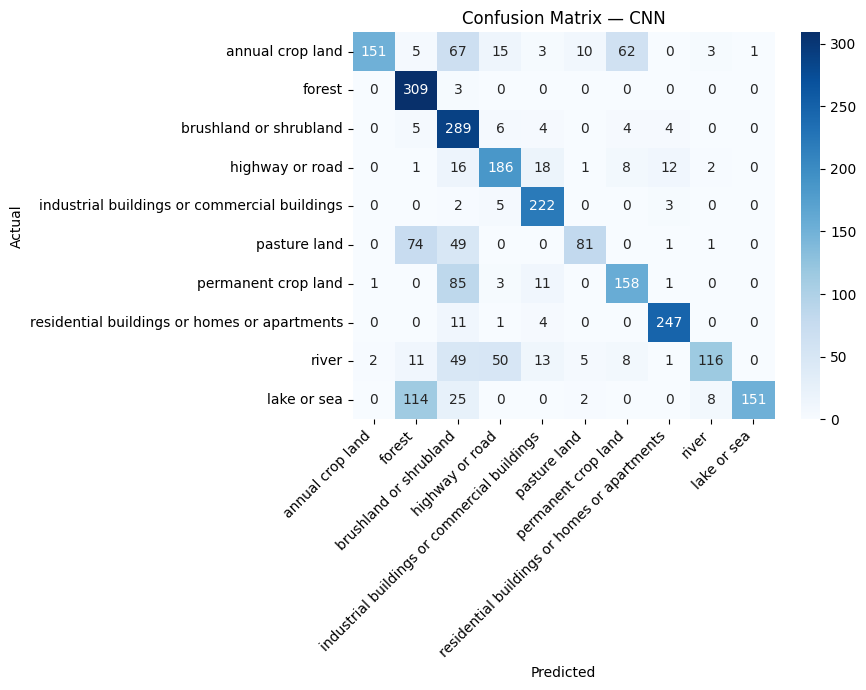

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Gather all predictions and true labels over the test set
y_true, y_pred_cnn = [], []
for images, labels in test_pipeline:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_cnn.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred_cnn = np.array(y_pred_cnn)

cm = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

                                              precision    recall  f1-score   support

                            annual crop land       0.98      0.48      0.64       317
                                      forest       0.60      0.99      0.74       312
                      brushland or shrubland       0.48      0.93      0.64       312
                             highway or road       0.70      0.76      0.73       244
industrial buildings or commercial buildings       0.81      0.96      0.88       232
                                pasture land       0.82      0.39      0.53       206
                         permanent crop land       0.66      0.61      0.63       259
residential buildings or homes or apartments       0.92      0.94      0.93       263
                                       river       0.89      0.45      0.60       255
                                 lake or sea       0.99      0.50      0.67       300

                                    accuracy        

### Discussion point

Look at the largest off-diagonal values in the confusion matrix — which two classes get confused most
often? In EuroSAT, **Highway** and **River** are common confusions (both are long, thin linear features),
and **AnnualCrop** / **PermanentCrop** / **Pasture** frequently overlap (all are vegetated agricultural
land with similar texture at 64×64 resolution). This mirrors a real point from the FDP lecture: **class
transitions in land cover are gradients, not hard edges** — which is exactly why dense segmentation
models like U-Net, not simple classifiers, are used for production land-cover mapping at pixel
resolution.

Total misclassified: 790 out of 2700 (29.3%)


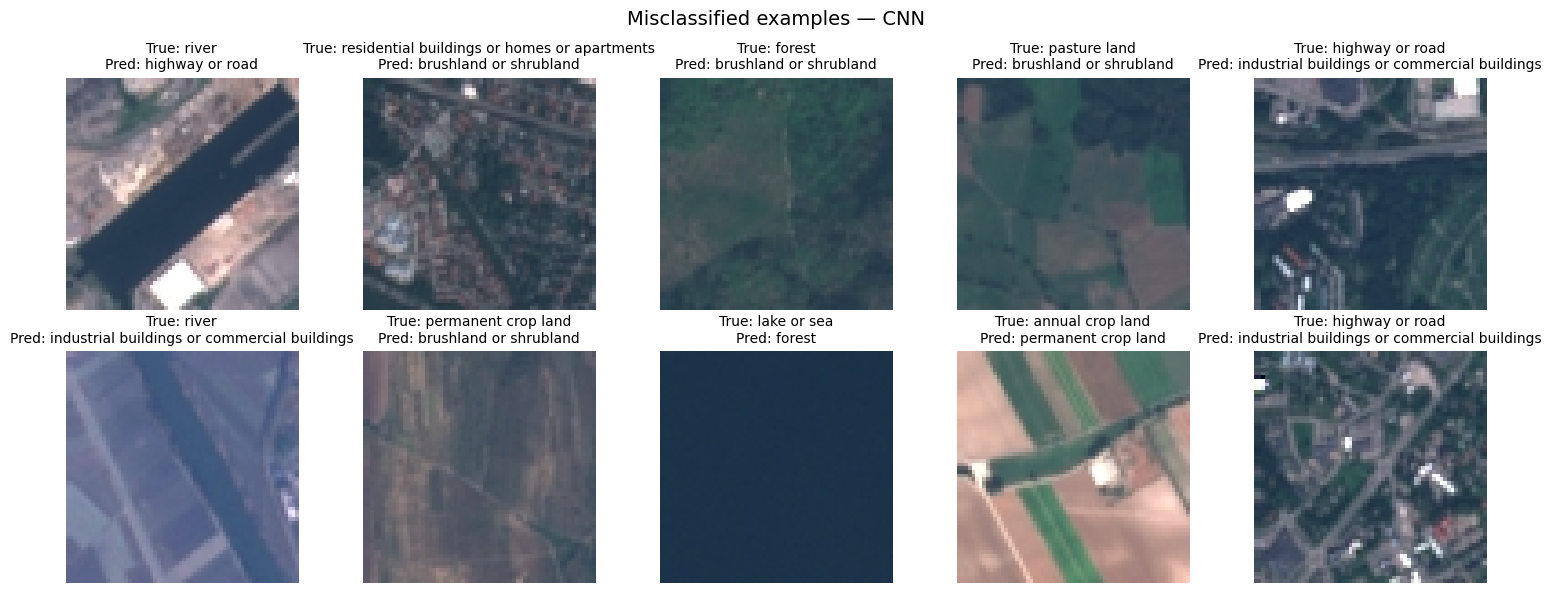

In [15]:
# Show some genuine misclassifications — always more instructive than aggregate metrics
wrong_indices = np.where(y_true != y_pred_cnn)[0]
print(f"Total misclassified: {len(wrong_indices)} out of {len(y_true)} ({len(wrong_indices)/len(y_true):.1%})")

# Re-collect images (small dataset, fine to redo this loop for visualization)
all_images = []
for images, _ in test_pipeline:
    all_images.extend(images.numpy())
all_images = np.array(all_images)

sample_wrong = np.random.choice(wrong_indices, size=min(10, len(wrong_indices)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(sample_wrong):
    ax = axes[i // 5, i % 5]
    ax.imshow(all_images[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}", fontsize=10)
    ax.axis('off')
plt.suptitle("Misclassified examples — CNN", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Build & Train a Vision Transformer (ViT)

Now let's build a second, architecturally very different model for the exact same task: a **Vision
Transformer**. Instead of sliding convolutional filters across the image, a ViT:

1. Chops the image into small fixed-size **patches** (e.g., 8×8 pixels)
2. **Flattens and linearly projects** each patch into a vector — this is the "patch embedding," the
   direct visual analogue of a word embedding in NLP
3. Adds a **position embedding** so the model knows where each patch came from (a plain Transformer has
   no inherent sense of spatial order)
4. Feeds the sequence of patch embeddings through stacked **self-attention** blocks, where every patch
   can directly attend to every other patch — including ones far away in the image
5. Uses a special **classification token** that aggregates information from the whole sequence for the
   final prediction

This is a compact ViT, built from scratch, sized for a short training run on limited data — not the
production-scale ViT-Base or ViT-Large you'd see in a paper.

In [16]:
from tensorflow.keras import layers, models
import tensorflow as tf

PATCH_SIZE = 8
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # (64/8)^2 = 64 patches per image
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4
MLP_HEAD_UNITS = [128]


class PatchEmbedding(layers.Layer):
    """Splits an image into fixed-size patches and linearly projects each one,
    then adds a learned position embedding."""
    def __init__(self, patch_size, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)


class TransformerBlock(layers.Layer):
    """One self-attention + MLP block, the repeating unit of a Transformer encoder."""
    def __init__(self, projection_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim // num_heads, dropout=0.1
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(projection_dim * 2, activation='gelu'),
            layers.Dropout(0.1),
            layers.Dense(projection_dim),
            layers.Dropout(0.1),
        ])

    def call(self, x):
        # Pre-norm residual attention block
        x1 = self.norm1(x)
        attn_output = self.attention(x1, x1)
        x2 = x + attn_output          # residual connection 1
        x3 = self.norm2(x2)
        mlp_output = self.mlp(x3)
        return x2 + mlp_output        # residual connection 2


def build_vit(input_shape=(64, 64, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = PatchEmbedding(PATCH_SIZE, NUM_PATCHES, PROJECTION_DIM)(inputs)

    for _ in range(TRANSFORMER_LAYERS):
        x = TransformerBlock(PROJECTION_DIM, NUM_HEADS)(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)   # aggregate across all patch tokens

    for units in MLP_HEAD_UNITS:
        x = layers.Dense(units, activation='gelu')(x)
        x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)


vit_model = build_vit(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes)
vit_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 64, 64)         │        16,448 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 64, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 64, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 64, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,074 (625.29 KB)

 Trainable params: 160,074 (625.29 KB)

 Non-trainable params: 0 (0.00 B)

### What's different from the CNN, concretely

- **No convolutions, no pooling.** Every patch can attend to every other patch from the very first
  layer — a CNN needs many stacked layers before its receptive field covers the whole image; a ViT has
  global context immediately.
- **No built-in translation invariance.** A CNN's sliding filter naturally treats a pattern the same way
  regardless of where it appears in the image. A ViT has to *learn* this from data via the position
  embeddings — one reason ViTs typically need more training data than CNNs to reach the same accuracy.
- **Patch embedding is the direct analogue of tokenizing text** — this is literally the same Transformer
  block used in language models, just applied to a sequence of image patches instead of a sequence of
  words.

In [17]:
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print("ViT compiled and ready to train.")

vit_param_count = vit_model.count_params()
print(f"ViT parameter count: {vit_param_count:,}")
print(f"CNN parameter count: {cnn_param_count:,}  (for comparison)")

ViT compiled and ready to train.
ViT parameter count: 160,074
CNN parameter count: 111,946  (for comparison)


### Training the ViT

We'll train for the **same number of epochs** as the CNN, on the **same data pipeline**, so the
comparison later is fair. Watch the validation accuracy curve closely — it's normal, and expected, for
the ViT to converge more slowly than the CNN did on a dataset this size.

In [18]:
vit_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    ),
]

vit_train_start = time.time()

vit_history = vit_model.fit(
    train_pipeline,
    validation_data=test_pipeline,
    epochs=EPOCHS,   # same EPOCHS as the CNN, for a fair comparison
    callbacks=vit_callbacks,
)

vit_train_time = time.time() - vit_train_start
print(f"\nViT training time: {vit_train_time:.1f} seconds")
print(f"CNN training time was: {cnn_train_time:.1f} seconds  (for comparison)")

Epoch 1/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step - accuracy: 0.4615 - loss: 1.4521 - val_accuracy: 0.6052 - val_loss: 1.0850
Epoch 2/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6441 - loss: 0.9838 - val_accuracy: 0.6837 - val_loss: 0.8335
Epoch 3/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7036 - loss: 0.8319 - val_accuracy: 0.7059 - val_loss: 0.7995
Epoch 4/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7450 - loss: 0.7184 - val_accuracy: 0.7556 - val_loss: 0.6700
Epoch 5/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7769 - loss: 0.6405 - val_accuracy: 0.7667 - val_loss: 0.6208
Epoch 6/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7933 - loss: 0.5903 - val_accuracy: 0.8156 - val_loss: 0.5252
Epoch 7/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8079 - loss: 0.5428 - val_accuracy: 0.7878 - val_loss: 0.5878
Epoch 8/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.8216 - loss: 0.5084 - val_accu

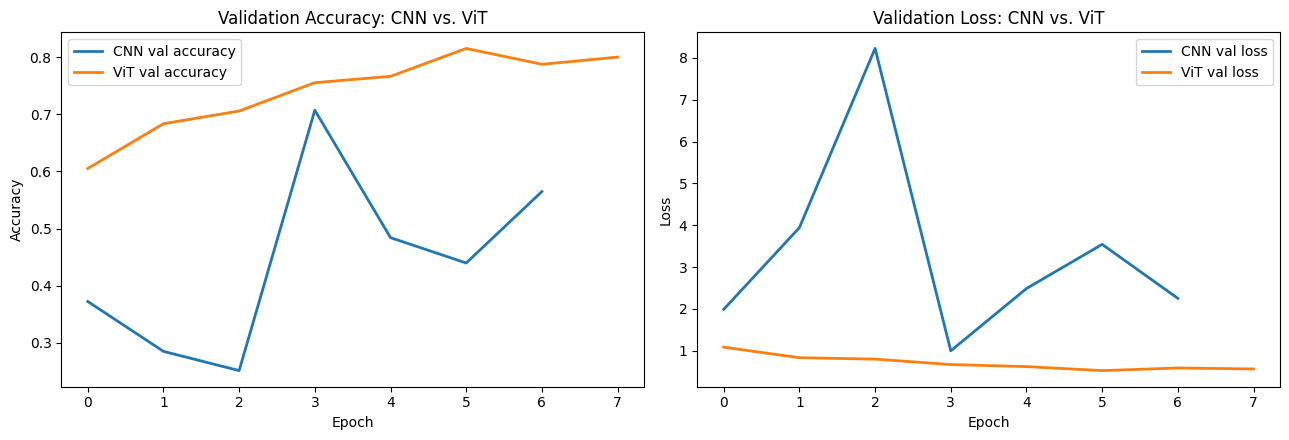

In [19]:
# Plot ViT training curves side-by-side with the CNN's, for a direct visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['val_accuracy'], label='CNN val accuracy', linewidth=2)
axes[0].plot(vit_history.history['val_accuracy'], label='ViT val accuracy', linewidth=2)
axes[0].set_title('Validation Accuracy: CNN vs. ViT')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['val_loss'], label='CNN val loss', linewidth=2)
axes[1].plot(vit_history.history['val_loss'], label='ViT val loss', linewidth=2)
axes[1].set_title('Validation Loss: CNN vs. ViT')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the ViT

Same evaluation procedure we used for the CNN — test accuracy, confusion matrix, and a look at what the
model gets wrong.

In [20]:
vit_test_loss, vit_test_accuracy = vit_model.evaluate(test_pipeline, verbose=0)
print(f"ViT test accuracy: {vit_test_accuracy:.2%}")
print(f"ViT test loss:     {vit_test_loss:.4f}")
print(f"\nCNN test accuracy was: {cnn_test_accuracy:.2%}  (for comparison)")

ViT test accuracy: 81.56%
ViT test loss:     0.5252

CNN test accuracy was: 70.74%  (for comparison)


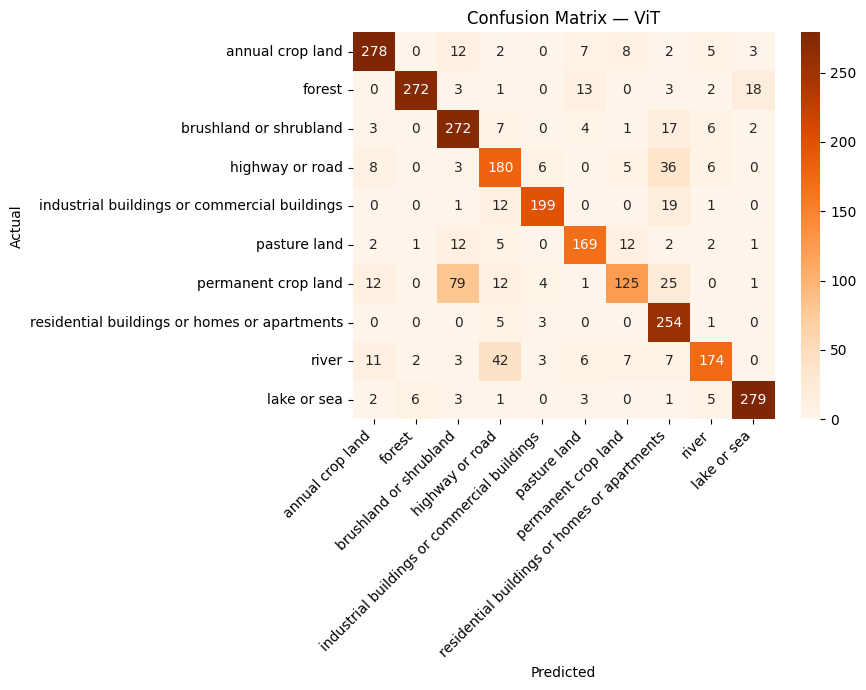

In [21]:
y_pred_vit = []
for images, labels in test_pipeline:
    preds = vit_model.predict(images, verbose=0)
    y_pred_vit.extend(np.argmax(preds, axis=1))

y_pred_vit = np.array(y_pred_vit)

cm_vit = confusion_matrix(y_true, y_pred_vit)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — ViT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_true, y_pred_vit, target_names=class_names))

                                              precision    recall  f1-score   support

                            annual crop land       0.88      0.88      0.88       317
                                      forest       0.97      0.87      0.92       312
                      brushland or shrubland       0.70      0.87      0.78       312
                             highway or road       0.67      0.74      0.70       244
industrial buildings or commercial buildings       0.93      0.86      0.89       232
                                pasture land       0.83      0.82      0.83       206
                         permanent crop land       0.79      0.48      0.60       259
residential buildings or homes or apartments       0.69      0.97      0.81       263
                                       river       0.86      0.68      0.76       255
                                 lake or sea       0.92      0.93      0.92       300

                                    accuracy        

## 8. Head-to-Head Comparison: CNN vs. ViT

Now let's put both models side by side on every axis that actually matters in practice — not just
accuracy, but training time and model size, which drive real deployment decisions.

In [23]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN', 'Vision Transformer'],
    'Test Accuracy': [cnn_test_accuracy, vit_test_accuracy],
    'Parameters': [cnn_param_count, vit_param_count],
    'Training Time (s)': [cnn_train_time, vit_train_time],
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].map(lambda x: f"{x:.2%}")
comparison['Parameters'] = comparison['Parameters'].map(lambda x: f"{x:,}")
comparison['Training Time (s)'] = comparison['Training Time (s)'].map(lambda x: f"{x:.1f}")

comparison

,Model,Test Accuracy,Parameters,Training Time (s)
0,CNN,70.74%,"111,946",181.0
1,Vision Transformer,81.56%,"160,074",239.7


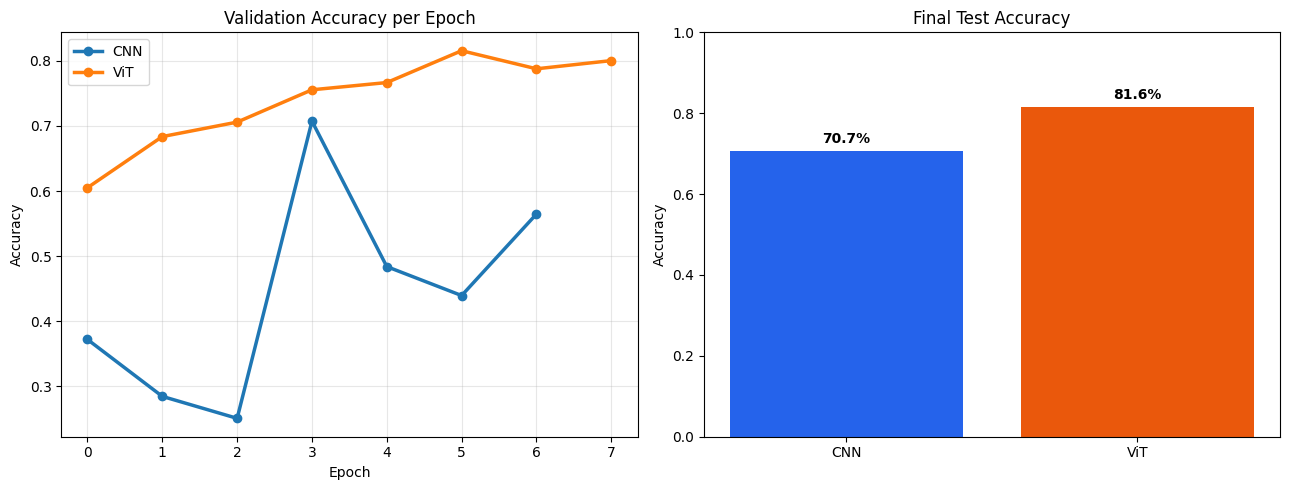

In [24]:
# Visual comparison: validation accuracy curves + final bar chart, together
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['val_accuracy'], label='CNN', linewidth=2.5, marker='o')
axes[0].plot(vit_history.history['val_accuracy'], label='ViT', linewidth=2.5, marker='o')
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

models_bar = ['CNN', 'ViT']
final_acc = [cnn_test_accuracy, vit_test_accuracy]
bars = axes[1].bar(models_bar, final_acc, color=['#2563eb', '#ea580c'])
axes[1].set_title('Final Test Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
for bar, acc in zip(bars, final_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.1%}",
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Reading this comparison — the actual lesson

On a dataset this size (~21,600 training images) and this few epochs, expect the **CNN to outperform the
ViT** on raw accuracy, and likely to train faster too. This is not a flaw in the ViT — it is exactly the
trade-off named in the lecture session:

- **CNNs have a useful inductive bias built in** — the sliding-filter structure assumes nearby pixels
  are related and that patterns are translation-invariant. That assumption happens to be true for images,
  so the CNN gets a head start and needs less data to exploit it.
- **Transformers have almost no built-in assumptions about images** — they have to learn spatial
  structure entirely from data via the position embeddings. With more data and more training time (or,
  in practice, with large-scale pretraining), this lack of built-in bias becomes an *advantage* — the
  model can learn relationships a CNN's local receptive field would never capture directly, like relating
  a river three kilometers away to flood risk at the current pixel.
- **This is exactly why production Earth Observation systems rarely train a ViT from scratch.** Instead,
  they start from a ViT that has already been pretrained on a massive unlabeled archive — Prithvi,
  SatMAE, PhilEO — and fine-tune it. Pretraining is what supplies the data volume a ViT needs; without
  it, on a small labeled set like ours, a plain CNN is often simply the better choice.
- **Hybrid architectures — a CNN backbone feeding into transformer blocks — exist precisely to get the
  best of both:** convolutional inductive bias for data efficiency, plus attention for long-range
  context, without needing either extreme.

### When would you actually reach for each one?

| Situation | Better choice |
|---|---|
| Small labeled dataset, need results fast | CNN |
| Large labeled dataset, or a pretrained backbone available | Transformer / ViT |
| Need to relate distant regions of an image (e.g., river → flood risk far away) | Transformer / hybrid |
| Tight compute or edge deployment budget | CNN (generally smaller, faster inference) |
| State-of-the-art accuracy is the only priority, and data/compute are not constraints | Transformer / hybrid, ideally pretrained |

## 9. Run Inference on Your Own Image + Wrap-Up

Let's use the trained model to classify a single new image — this is the same `model.predict()` pattern
used in a real deployment pipeline, whether that's a batch job over new satellite tiles or a live
inference endpoint.

Actual class: industrial buildings or commercial buildings

[CNN] Predicted: industrial buildings or commercial buildings  (confidence: 74.0%)
    industrial buildings or commercial buildings 74.0%
    brushland or shrubland 22.5%
    permanent crop land  2.2%

[ViT] Predicted: brushland or shrubland  (confidence: 97.4%)
    brushland or shrubland 97.4%
    highway or road      0.9%
    permanent crop land  0.7%



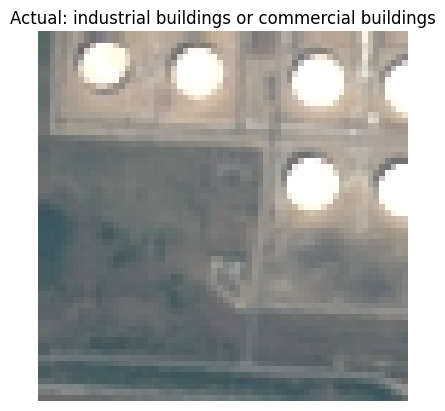

In [25]:
def predict_single(image_batch_of_one, which_model=model, model_name="CNN"):
    """image_batch_of_one: a normalized (1, 64, 64, 3) array"""
    probs = which_model.predict(image_batch_of_one, verbose=0)[0]
    predicted_class = class_names[np.argmax(probs)]
    confidence = np.max(probs)

    top3_idx = np.argsort(probs)[-3:][::-1]
    print(f"[{model_name}] Predicted: {predicted_class}  (confidence: {confidence:.1%})")
    for idx in top3_idx:
        print(f"    {class_names[idx]:20s} {probs[idx]:.1%}")
    print()

# Try both models on the same random test image, side by side
random_idx = np.random.randint(0, len(all_images))
sample = np.expand_dims(all_images[random_idx], axis=0)
print(f"Actual class: {class_names[y_true[random_idx]]}\n")

predict_single(sample, which_model=model, model_name="CNN")
predict_single(sample, which_model=vit_model, model_name="ViT")

plt.imshow(sample[0])
plt.title(f"Actual: {class_names[y_true[random_idx]]}")
plt.axis('off')
plt.show()

In [26]:
'''from google.colab import files
from PIL import Image

uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = Image.open(fname).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img).astype(np.float32) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

predict_single(img_batch, which_model=model, model_name="CNN")
predict_single(img_batch, which_model=vit_model, model_name="ViT")'''

'from google.colab import files\nfrom PIL import Image\n\nuploaded = files.upload()\nfname = list(uploaded.keys())[0]\n\nimg = Image.open(fname).convert(\'RGB\').resize((IMG_SIZE, IMG_SIZE))\nimg_array = np.array(img).astype(np.float32) / 255.0\nimg_batch = np.expand_dims(img_array, axis=0)\n\npredict_single(img_batch, which_model=model, model_name="CNN")\npredict_single(img_batch, which_model=vit_model, model_name="ViT")'

In [27]:
# Save both trained models so you can reload them later without retraining
model.save('eurosat_cnn_model.keras')
vit_model.save('eurosat_vit_model.keras')
print("Saved eurosat_cnn_model.keras and eurosat_vit_model.keras")

# To reload later:
#model = tf.keras.models.load_model('eurosat_cnn_model.keras')
#vit_model = tf.keras.models.load_model('eurosat_vit_model.keras')

Saved eurosat_cnn_model.keras and eurosat_vit_model.keras


---

## Wrap-Up: What We Covered, and Where to Go Next

In 105 minutes, we went through the full applied ML workflow end to end, **twice, on two different
architectures** — and compared them directly rather than just building one model in isolation:

1. **Data loading & exploration** — understanding class balance and raw inputs before touching a model
2. **Preprocessing pipelines** — normalization, batching, and augmentation, and why the test set is
   treated differently from the training set
3. **CNN architecture** — a stacked Conv/BatchNorm/Pool network, and how each layer type contributes
4. **Vision Transformer architecture** — patch embedding, position embedding, and self-attention blocks,
   built from scratch
5. **Training both**, on identical data and epoch budgets, for a fair comparison
6. **Evaluation** — going beyond a single accuracy number to confusion matrices and real misclassified
   examples, for both models
7. **Head-to-head comparison** — accuracy, training time, and parameter count, and *why* the CNN likely
   won on this dataset size
8. **Inference** — running both trained models on a new, unseen image side by side

### Extending this notebook on your own

- **Swap in a pretrained backbone** (e.g., `tf.keras.applications.EfficientNetB0` with `include_top=False`,
  or a pretrained ViT from `keras.applications` / HuggingFace) and fine-tune instead of training from
  scratch — this is exactly how the ViT's data-hunger disadvantage gets neutralized in real EO systems.
- **Move from classification to segmentation** — the natural next step is a U-Net that predicts a class
  for every pixel rather than one label per patch; the encoder half reuses the same Conv/Pool blocks
  built in this notebook.
- **Try a hybrid architecture** — a CNN backbone feeding its feature maps into a few transformer blocks,
  combining the CNN's data efficiency with the Transformer's long-range attention.
- **Try the full 13-band Sentinel-2 version of EuroSAT** (`eurosat/all` instead of `eurosat/rgb`) — both
  architectures adapt with a one-line change to the input channel count.
- **Add explainability** — Grad-CAM for the CNN, attention-map visualization for the ViT — directly
  relevant to the interpretability material from the lecture session, and a natural way to *see* the
  difference in what each architecture is "looking at."

### Resources

- EuroSAT dataset & paper: https://github.com/phelber/EuroSAT
- TensorFlow/Keras documentation: https://www.tensorflow.org/guide/keras
- "An Image is Worth 16x16 Words" (the original ViT paper): https://arxiv.org/abs/2010.11929
- Google Earth Engine (for accessing real, current Sentinel-2 imagery): https://earthengine.google.com

---

**Er. Abhishek Kumar Shukla**
Senior AI Developer, UniConverge Technologies Pvt. Ltd.
